<a href="https://colab.research.google.com/github/vtecftwy/utseus-dives/blob/main/nbs/cv_0_image-processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Processing images with PIL

In [1]:
from PIL import Image, ImageOps, ImageFilter, ImageTransform, ImageEnhance
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load image and basic transformation

Size: (1654, 926)


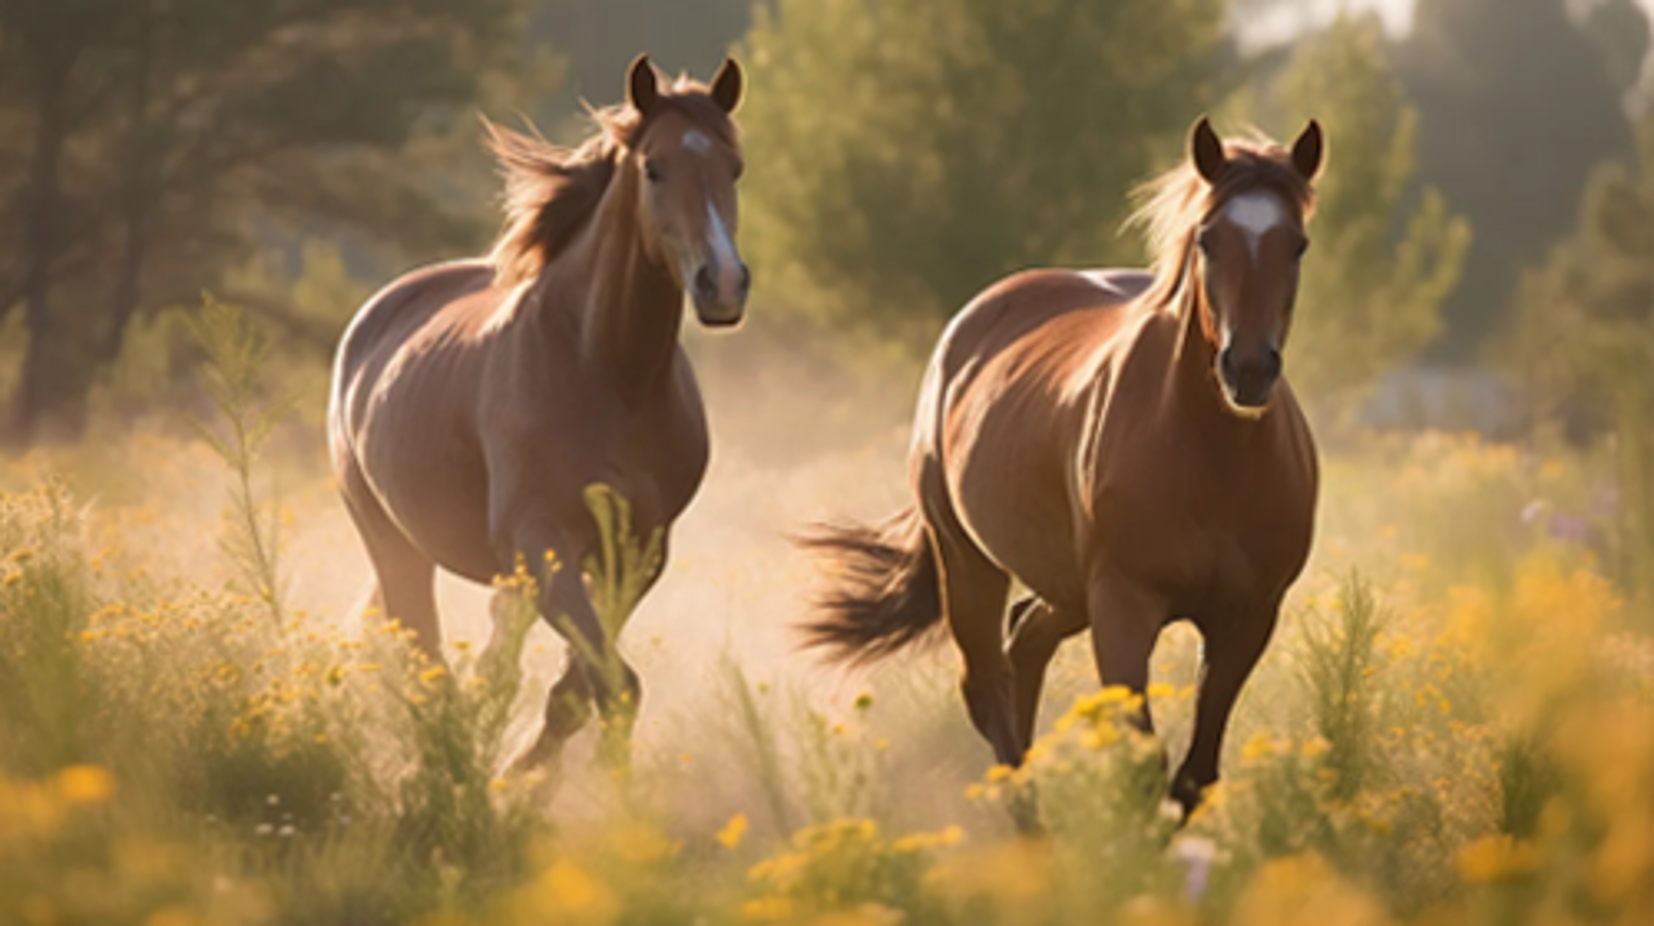

In [2]:
im = Image.open('horse.png')
print(f"Size: {im.size}")
im

Resize image (need to define exactly the width and height)

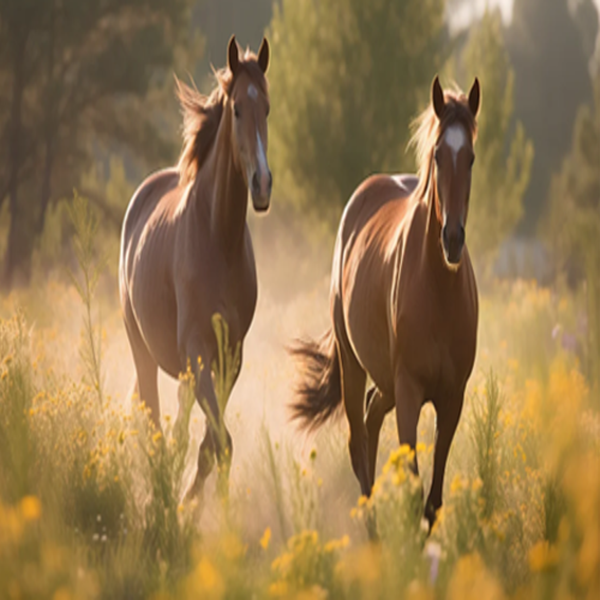

In [3]:
im.resize((600,600))

Resize the image while keeping the aspect ration

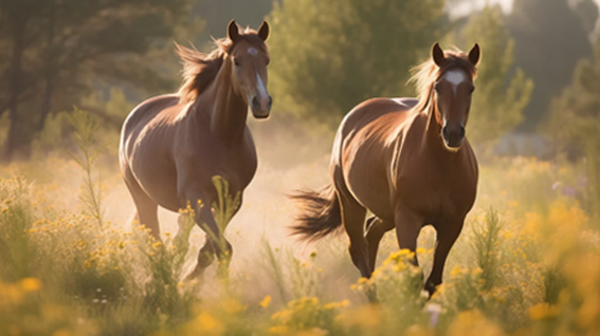

In [4]:
max_size=(600,600)
im_sm = ImageOps.contain(im, max_size, method=Image.Resampling.LANCZOS)
im_sm

Crop an image.

`Image.crop` takes a crop box defined by `(a,b)` the top left corner of the box and `(c,d)` the bottom right corner of the box.

To make it more natural, we define the box using top left corner `(a,b)` and box width and height `(w,h)`

(1654, 926)


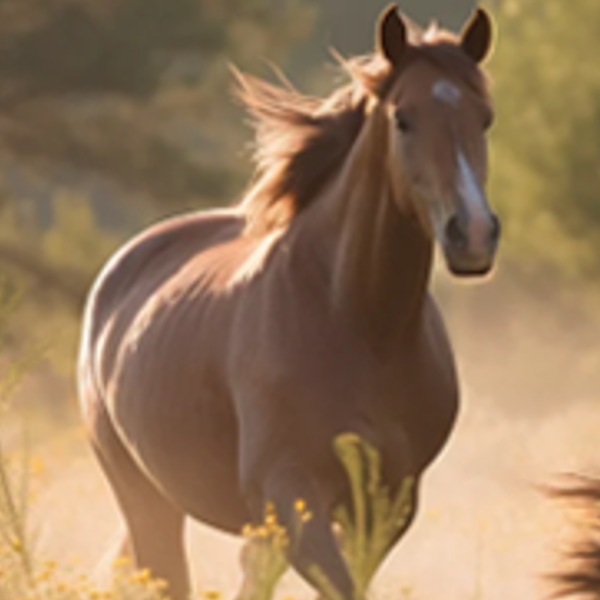

In [5]:
im = Image.open('horse.png')
print(im.size)

a,b,w,h = 250, 50, 600, 600
im_cropped = im.crop((a,b,a+w,b+h))
im_cropped

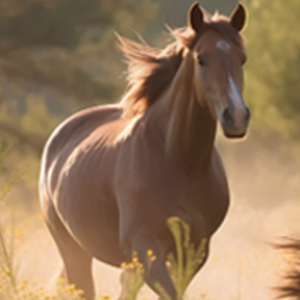

In [6]:
im_cropped_sm = im_cropped.resize((300, 300))
im_cropped_sm

# Image representation (array)

In [7]:
im_array = np.array(im_cropped_sm)
print(im_array.shape)

(300, 300, 4)


It has 4 channels, not 3

In [8]:
im.mode

'RGBA'

We see that the image is a RGBA image. We do not need the transparency mask, so we will drop it.

In [9]:
im_cropped_sm = im_cropped_sm.convert('RGB')
im_array = np.array(im_cropped_sm)
print(im_array.shape)
im_array_r, im_array_g, im_array_b = im_array[:,:,0], im_array[:,:,1], im_array[:,:,2]

(300, 300, 3)


Let's explore the three channels:

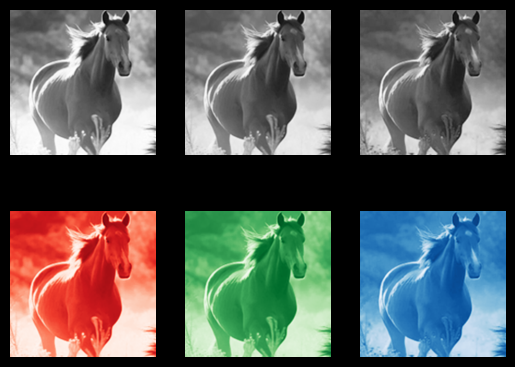

In [10]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2,3)
for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.axis('off')
ax1.imshow(im_array_r, cmap='Greys_r')
ax2.imshow(im_array_g, cmap='Greys_r')
ax3.imshow(im_array_b, cmap='Greys_r')
ax4.imshow(im_array_r, cmap='Reds_r')
ax5.imshow(im_array_g, cmap='Greens_r')
ax6.imshow(im_array_b, cmap='Blues_r')
plt.show()

Let's look as a small section of the image and explore the intensity values in details

In [11]:
im = Image.open('horse.png')
max_size=(300,300)
im_sm = ImageOps.contain(im, max_size, method=Image.Resampling.LANCZOS)
im_sm = im_sm.convert('RGB')
print('image size:',im_sm.size)
a,b,w,h = 110, 15, 25, 25
im_crop = im_sm.crop((a,b,a+w,b+h))
display(im_crop)
print('cropped image size:',im_crop.size)
im_array = np.array(im_crop)
im_array_r, im_array_g, im_array_b = im_array[:,:,0], im_array[:,:,1], im_array[:,:,2]

image size: (300, 168)


cropped image size: (25, 25)


In [12]:
im_array[:5, :5, 0]

array([[105, 104,  99, 141,  92],
       [105, 104,  98, 147,  98],
       [105, 102,  97, 157, 118],
       [102, 112, 128, 181, 165],
       [179, 173, 173, 229, 229]], dtype=uint8)

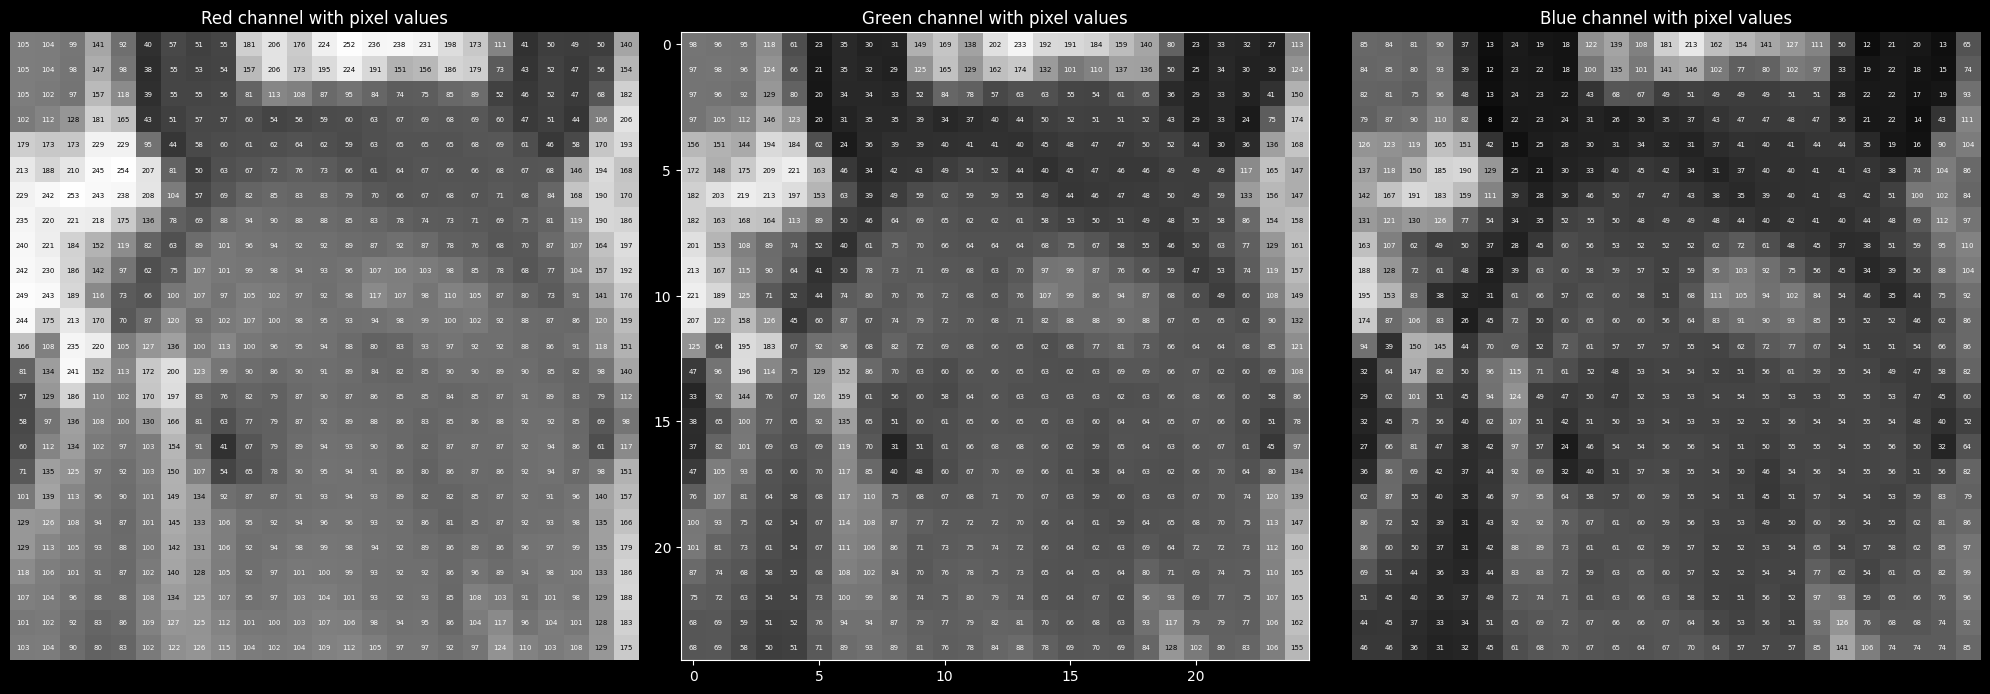

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 10))
ax1.imshow(im_array_r, cmap="Greys_r", vmin=0, vmax=255)
ax1.set_title("Red channel with pixel values")
ax1.axis("off")
ax2.imshow(im_array_g, cmap="Greys_r", vmin=0, vmax=255)
ax2.set_title("Green channel with pixel values")
ax1.axis("off")
ax3.imshow(im_array_b, cmap="Greys_r", vmin=0, vmax=255)
ax3.set_title("Blue channel with pixel values")
ax3.axis("off")

# Overlay value text with contrast-aware text color
for array, ax in zip([im_array_r, im_array_g, im_array_b], [ax1, ax2, ax3]):
    for i in range(array.shape[0]):
        for j in range(array.shape[1]):
            v = int(array[i, j])
            txt_color = "white" if v < 128 else "black"
            ax.text(j, i, str(v), ha="center", va="center", color=txt_color, fontsize=5)

plt.tight_layout()
plt.show()

In [14]:
im_array_normalized = im_array / 255
im_array_normalized_r, im_array_normalized_g, im_array_normalized_b = im_array_normalized[:,:,0], im_array_normalized[:,:,1], im_array_normalized[:,:,2]
im_array_normalized[:5, :5, 0]

array([[0.41176471, 0.40784314, 0.38823529, 0.55294118, 0.36078431],
       [0.41176471, 0.40784314, 0.38431373, 0.57647059, 0.38431373],
       [0.41176471, 0.4       , 0.38039216, 0.61568627, 0.4627451 ],
       [0.4       , 0.43921569, 0.50196078, 0.70980392, 0.64705882],
       [0.70196078, 0.67843137, 0.67843137, 0.89803922, 0.89803922]])

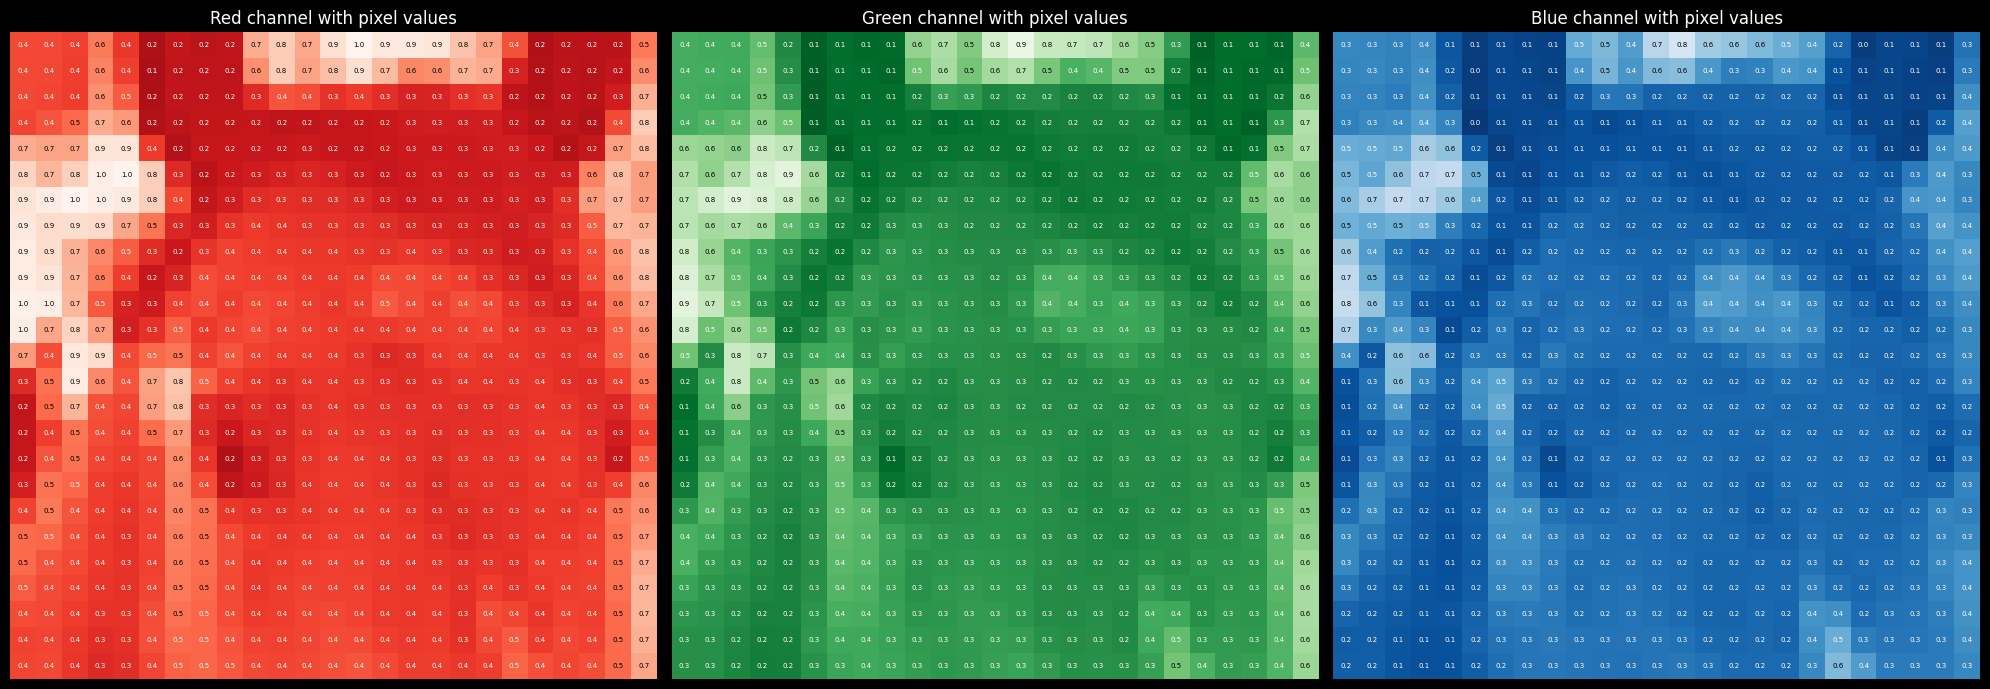

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 10))
ax1.imshow(im_array_normalized_r, cmap="Reds_r", vmin=0, vmax=1)
ax1.set_title("Red channel with pixel values")
ax1.axis("off")
ax2.imshow(im_array_normalized_g, cmap="Greens_r", vmin=0, vmax=1)
ax2.set_title("Green channel with pixel values")
ax2.axis("off")
ax3.imshow(im_array_normalized_b, cmap="Blues_r", vmin=0, vmax=1)
ax3.set_title("Blue channel with pixel values")
ax3.axis("off")

# Overlay value text with contrast-aware text color
for array, ax in zip([im_array_normalized_r, im_array_normalized_g, im_array_normalized_b], [ax1, ax2, ax3]):
    for i in range(array.shape[0]):
        for j in range(array.shape[1]):
            v = array[i, j]
            txt_color = "white" if v < 0.5 else "black"
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", color=txt_color, fontsize=5)

plt.tight_layout()
plt.show()

# Image Transformation

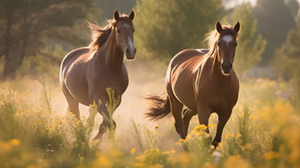

In [16]:
im_sm

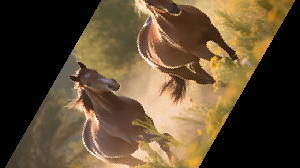

In [17]:
im_sm.rotate(60, expand=False)

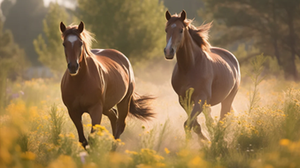

In [18]:
im_sm.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

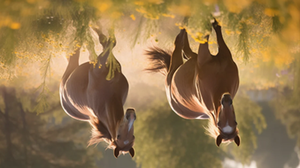

In [19]:
im_sm.transpose(Image.Transpose.FLIP_TOP_BOTTOM)

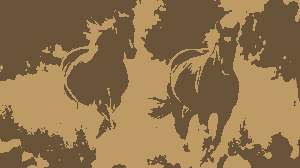

In [20]:
im_sm.quantize(colors=2, method=Image.Quantize.MEDIANCUT)

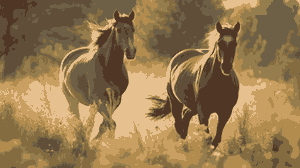

In [21]:
im_sm.quantize(colors=8, method=Image.Quantize.MEDIANCUT)

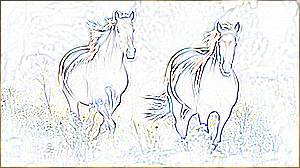

In [22]:
im_sm.filter(ImageFilter.CONTOUR)

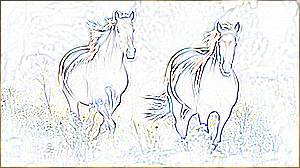

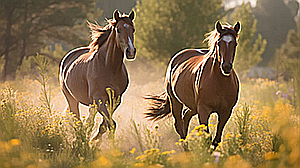

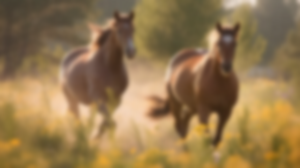

In [23]:
display(im_sm.filter(ImageFilter.CONTOUR))
display(im_sm.filter(ImageFilter.EDGE_ENHANCE))
display(im_sm.filter(ImageFilter.GaussianBlur(radius=2)))

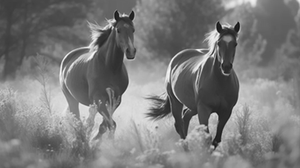

In [24]:
im_sm.convert('L')

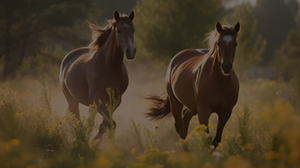

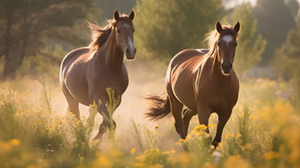

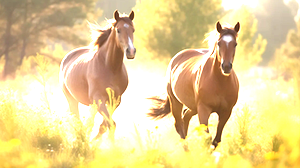

In [25]:
display(ImageEnhance.Brightness(im_sm).enhance(0.5))
display(ImageEnhance.Brightness(im_sm).enhance(1))
display(ImageEnhance.Brightness(im_sm).enhance(2))

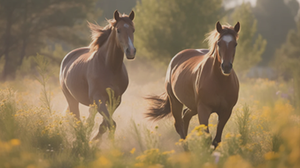

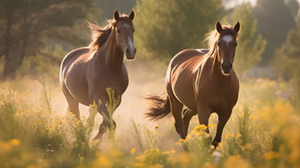

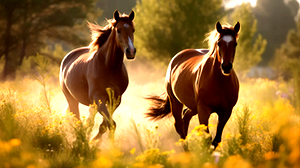

In [26]:
display(ImageEnhance.Contrast(im_sm).enhance(0.75))
display(ImageEnhance.Contrast(im_sm).enhance(1))
display(ImageEnhance.Contrast(im_sm).enhance(1.75))

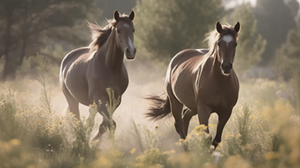

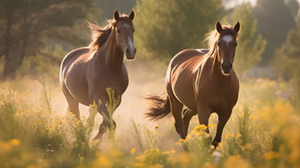

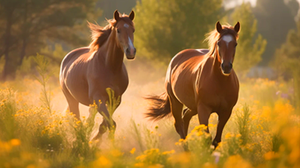

In [27]:
display(ImageEnhance.Color(im_sm).enhance(0.5))
display(ImageEnhance.Color(im_sm).enhance(1))
display(ImageEnhance.Color(im_sm).enhance(1.5))

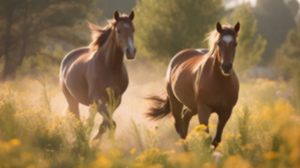

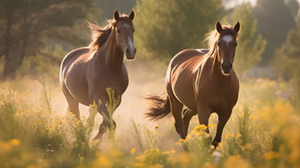

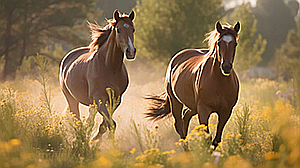

In [28]:
display(ImageEnhance.Sharpness(im_sm).enhance(0.1))
display(ImageEnhance.Sharpness(im_sm).enhance(1))
display(ImageEnhance.Sharpness(im_sm).enhance(5))

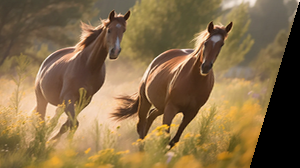

In [29]:
display(im_sm.transform(
    im_sm.size,
    Image.Transform.AFFINE,
    (1, 0.3, 0,   0, 1, 0),
    resample=Image.Resampling.BICUBIC
))


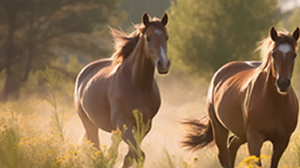

In [30]:
# Scale down to 80% (content appears smaller in frame)
display(im_sm.transform(
    im_sm.size,
    Image.Transform.AFFINE,
    (0.8, 0, 0,   0, 0.8, 0),
    resample=Image.Resampling.BICUBIC
))

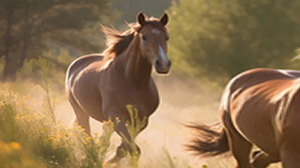

In [31]:
# Perspective: squeeze right side inward
display(im_sm.transform(
    im_sm.size,
    Image.Transform.PERSPECTIVE,
    (1, 0, 0,   0, 1, 0,   0.0015, 0),
    resample=Image.Resampling.BICUBIC
))

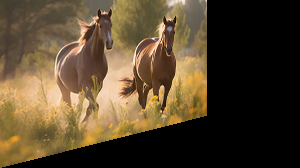

In [32]:
# Perspective: squeeze left side inward (opposite direction)
display(im_sm.transform(
    im_sm.size,
    Image.Transform.PERSPECTIVE,
    (1, 0, 0, 0, 1, 0, -0.0015, 0),
    resample=Image.Resampling.BICUBIC
))

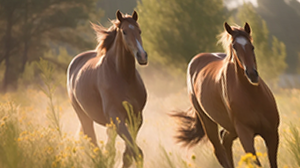

In [33]:
# Perspective: top/bottom keystone
display(im_sm.transform(
    im_sm.size,
    Image.Transform.PERSPECTIVE,
    (1, 0, 0,   0, 1, 0,   0, 0.0015),
    resample=Image.Resampling.BICUBIC
))

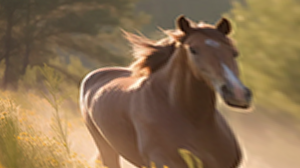

In [34]:
# Stronger perspective + white background for uncovered areas
display(im_sm.transform(
    im_sm.size,
    Image.Transform.PERSPECTIVE,
    (1, 0, 0,   0, 1, 0,   0.003, 0.001),
    resample=Image.Resampling.BICUBIC,
    fillcolor=(255, 255, 255)
))

# Kernel - Convolution

In [35]:
def apply_kernel(im, kernel, scale=1, offset=128):
    return im.filter(
        ImageFilter.Kernel(
            size=(3, 3),
            kernel=kernel,
            scale=scale,
            offset=offset,
        )
    )

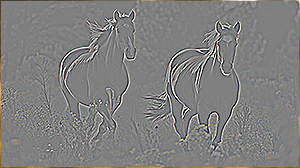

In [36]:
kernel = [
     0, -1,  0,
    -1,  4, -1,
     0, -1,  0
]
apply_kernel(im_sm, kernel)

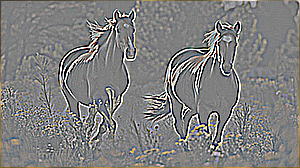

In [37]:
kernel = [
    -1, -1, -1,
    -1,  8, -1,
    -1, -1, -1
]
apply_kernel(im_sm, kernel)

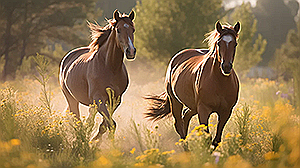

In [38]:
kernel = [
      0, -1,  0,
     -1,  5, -1,
      0, -1,  0
]
apply_kernel(im_sm, kernel, offset=0)

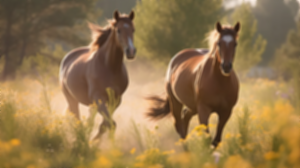

In [39]:
kernel = [
      1, 1, 1,
      1, 1, 1,
      1, 1, 1
]
apply_kernel(im_sm, kernel, scale=9, offset=0)

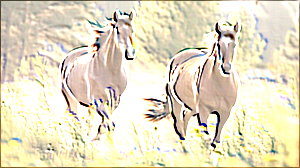

In [40]:
kernel = [
    -2,-1,0, 
    -1,1,1, 
    0,1,2
]
apply_kernel(im_sm, kernel, scale=1, offset=128)

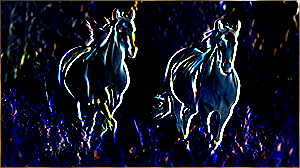

In [41]:
kernel = [
    -10,-2,9, 
    -1,1,1, 
    0,0,0
]
apply_kernel(im_sm, kernel, scale=1, offset=128)

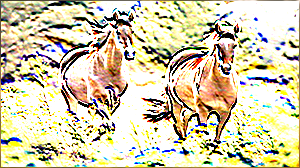

In [52]:
import random
kernel = [random.randint(-15, 15) for i in range(9)]
kernel


apply_kernel(im_sm, kernel=kernel, offset=0)